### **Checando lang detect**

Este notebook compara as mensagens que foram avaliadas como não inglês pelo langdetect com o resultado do roberta

---

In [1]:
import os
import json
import pandas as pd
from langdetect import detect, DetectorFactory
import numpy as np
from tqdm import tqdm
import pandas as pd
from multiprocessing import Pool, cpu_count

In [2]:
rows = []
erros = []

# Itera por cada profundidade
for depth in range(3 + 1):
    dir_ = f"../data/raw/expansao/{depth}/subreddits"
    if not os.path.exists(dir_):
        continue
    for filename in os.listdir(dir_):
        if filename.endswith(".json"):
            path = os.path.join(dir_, filename)
            try:
                with open(path, "r", encoding="utf-8") as f:
                    posts = json.load(f)
                # Adiciona a profundidade em cada post para rastreabilidade
                for post in posts:
                    post["depth"] = depth
                rows.extend(posts)
            except json.JSONDecodeError:
                erros.append(path)


df = pd.DataFrame(rows)

print(f"Arquivos com erro: {len(erros)}")
print(f"Quantidade de subreddits únicos: {df['subreddit'].nunique()}")
print(f"Quantidade de autores únicos: {df['author'].nunique()}")
print(f"Quantidade de posts carregados: {len(df)}")

Arquivos com erro: 0
Quantidade de subreddits únicos: 7372
Quantidade de autores únicos: 1202164
Quantidade de posts carregados: 2227113


In [4]:
df_2 = pd.read_csv("../reports/lang_detection/checking_lang_detect.csv")

In [5]:
df_not_en = df[df['lang'] != 'en'].copy()

In [40]:
print(f"Quantidade de mensagens classificadas como não inglesas pelo langdetect: {len(df_not_en)}")
print(f"Quantidade de mensagens comparadas como roberta: {len(df_2)}")
df_not_en_r = df_2[df_2['lang_roberta']!='en'].copy()
print(f"Quantidade de mensagens classificadas como não inglesas pelo roberta: {len(df_not_en_r)}")
df_en_r = df_2[df_2['lang_roberta'] == 'en'].copy()
print(f"Quantidade de mensagens classificadas como inglesas pelo roberta e não inglesas pelo langdetect: {len(df_en_r)}, {(len(df_en_r)/len(df_not_en)*100):.2f}%")

Quantidade de mensagens classificadas como não inglesas pelo langdetect: 394783
Quantidade de mensagens comparadas como roberta: 394778
Quantidade de mensagens classificadas como não inglesas pelo roberta: 208540
Quantidade de mensagens classificadas como inglesas pelo roberta e não inglesas pelo langdetect: 186238, 47.17%


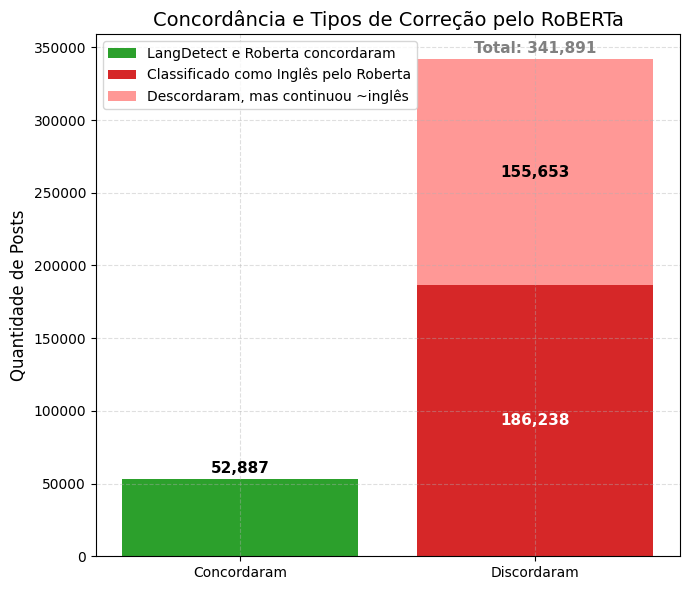

In [36]:
import matplotlib.pyplot as plt

concordaram = len(df_2[df_2['lang'] == df_2['lang_roberta']])
discordaram_en = len(df_2[(df_2['lang'] != df_2['lang_roberta']) & (df_2['lang_roberta'] == 'en')])
discordaram_outro = len(df_2[(df_2['lang'] != df_2['lang_roberta']) & (df_2['lang_roberta'] != 'en')])

fig, ax = plt.subplots(figsize=(7, 6))

plt.grid(True, which="both", ls="--", alpha=0.4)

ax.bar('Concordaram', concordaram, color='#2ca02c', label='LangDetect e Roberta concordaram')
ax.bar('Discordaram', discordaram_en, color='#d62728', label='Classificado como Inglês pelo Roberta')
ax.bar('Discordaram', discordaram_outro, bottom=discordaram_en, color='#ff9896', label='Descordaram, mas continuou ~inglês')

ax.text(0, concordaram + 2000, f'{concordaram:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.text(1, discordaram_en / 2, f'{discordaram_en:,}', ha='center', va='center', fontsize=11, fontweight='bold', color='white')
posicao_y_texto_claro = discordaram_en + (discordaram_outro / 2)
ax.text(1, posicao_y_texto_claro, f'{discordaram_outro:,}', ha='center', va='center', fontsize=11, fontweight='bold', color='black')

total_discordaram = discordaram_en + discordaram_outro
ax.text(1, total_discordaram + 2000, f'Total: {total_discordaram:,}', ha='center', va='bottom', fontsize=11, fontweight='bold', color='gray')

plt.title('Concordância e Tipos de Correção pelo RoBERTa', fontsize=14)
plt.ylabel('Quantidade de Posts', fontsize=12)

plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
df = df.drop_duplicates('id')
df_en = df[df['lang'] == 'en']
print(f"Porcentagem de mensagens em inglês pelo langdetect: {(len(df_en)/len(df)*100):.2f}")
print(f"Porcentagem de mensagens em inglês pelo langdetect + checagem roberta: {((len(df_en)+len(df_en_r))/len(df)*100):.2f}")

Porcentagem de mensagens em inglês pelo langdetect: 82.30
Porcentagem de mensagens em inglês pelo langdetect + checagem roberta: 91.02


In [45]:
df_processed = pd.read_csv("../data/processed/preprocess_text.csv")
df_processed

,id,text,text_clean
0,1j3g0q5,Trudeau - ''I want to speak first directly to ...,trudeau want speak first directly american peo...
1,1jdfbt3,Kim Kardashian endorses Nazi Elon Musk’s cyber...,kardashian endorses nazi elon musk cybertruck ...
2,1k7jcux,Candace Owens saying she no longer supports Do...,candace owen long support donald trump
3,1ilwij6,Kendrick Lamar called out for no white perform...,kendrick lamar call white performer super bowl...
4,1jfzx63,"Elon Musk's daughter, Vivian Wilson, stars in ...",elon musk daughter vivian wilson star first ev...
...,...,...,...
2227108,14ifnii,iVentoy is out now! Ease of Ventoy with just o...,iventoy ease ventoy iventoy release exactly se...
2227109,zqyg79,I created a library of full-color SVG icons of...,create library full color icon homelab relate ...
2227110,c6e90e,When your friend texts you that Micro Center j...,friend text micro center shipment damn enjoy m...
2227111,r8kbmz,Not A typical Post but I hope it made you laug...,typical post hope make laugh browse github stu...


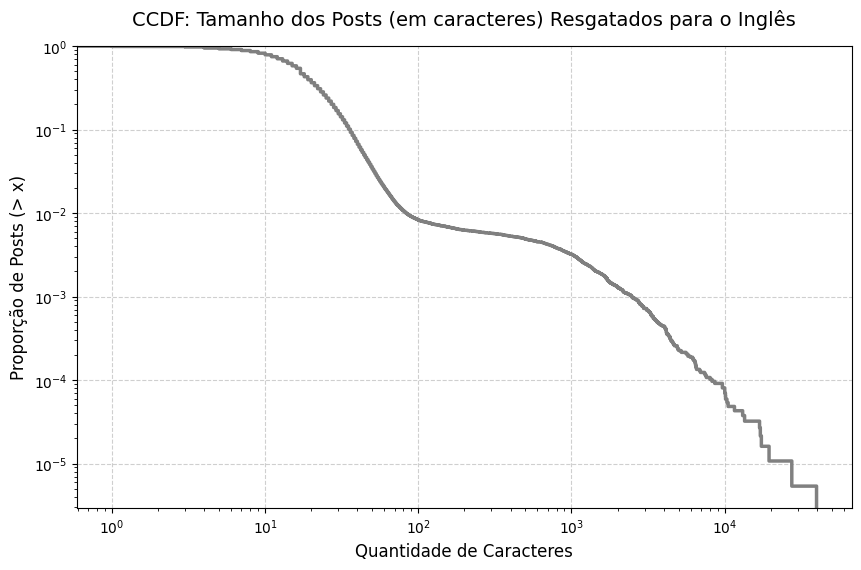

Estatísticas dos textos resgatados:
Mediana de caracteres: 17.0
Média de caracteres: 29.6


In [53]:
import seaborn as sns

discordaram_en_ids = df_2[(df_2['lang'] != df_2['lang_roberta']) & (df_2['lang_roberta'] == 'en')]['id']
df_alvo = df_processed[df_processed['id'].isin(discordaram_en_ids)].copy()
df_alvo['qtd_caracteres'] = df_alvo['text'].fillna('').astype(str).str.len()

plt.figure(figsize=(10, 6))

# Usamos o seaborn para gerar o CCDF (complementary=True)
sns.ecdfplot(data=df_alvo, x='qtd_caracteres', complementary=True, color='gray', linewidth=2.5)

# Títulos e Labels
plt.title('CCDF: Tamanho dos Posts (em caracteres) Resgatados para o Inglês', fontsize=14, pad=15)
plt.xlabel('Quantidade de Caracteres', fontsize=12)
plt.ylabel('Proporção de Posts (> x)', fontsize=12)

plt.grid(axis='both', linestyle='--', alpha=0.6)

plt.xscale('log')
plt.yscale('log')
plt.show()

# Extra: Exibindo algumas estatísticas descritivas para você usar no texto do TCC
mediana = df_alvo['qtd_caracteres'].median()
media = df_alvo['qtd_caracteres'].mean()
print(f"Estatísticas dos textos resgatados:")
print(f"Mediana de caracteres: {mediana}")
print(f"Média de caracteres: {media:.1f}")

Como conclusão vejo que conseguimos recuperar bastante posts que seriam descartados, já que a % de posts mantidos como inglês saltou de 82% para 91% do corpus, além disso a mediana de caracteres dentre estes posts resgatados é de 17 caracteres, provavelmente será mantido ainda uma parte